In [2]:
import sys
import os
import numpy as np

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
#cc_grn_functions_path = r"C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from quantum_functions import create_initial_circuit2, concatenate_circuits_with_separate_measurements, add_cnots_and_measurements_to_circuit
from quantum_functions import add_crx_gates_and_measurements_to_circuit, get_probability_distribution, calculate_kl_divergence
from quantum_functions import score_circuit_kl_divergences, plot_measurement_histograms, create_cnot_pairs_from_locations, optimize_crx_angles
from quantum_functions import vector_normalize_dictionary_values, find_best_cnot_sequence_brute_force, find_best_cnot_sequence_multi_epoch
from quantum_functions import find_best_cnot_sequence_iterative_n_wise

In [3]:
import numpy as np
import pandas as pd
import scanpy as sc 

np.random.seed(42) 

adata = sc.read_h5ad("dataset_co_mo2.h5ad")
# Data prep
sc.pp.normalize_total(adata, target_sum=1e4) # You can adjust target_sum # Seems not to help
sc.pp.log1p(adata)

In [4]:
gl_source = ['STAT3','IL6RorST','TGFBR1or2','PDGFB'] # All values from the first column
gl_recv =['PDGFRB', 'TGFB1', 'IL6']  # All values from the second column

In [5]:
ict1 = adata.obs["BatchID"] == "Cancer Cells (Co)"
ict2 = adata.obs["BatchID"] == "Fibroblasts (Co)" 

adata_ct1_co = adata[ict1, gl_source]
adata_ct2_co = adata[ict2, gl_recv]
#adata_ct1_co = sc.external.pp.magic(adata_ct1_co, name_list=gl_source, knn=5, random_state=42)
#adata_ct2_co = sc.external.pp.magic(adata_ct2_co, name_list=gl_recv, knn=5, random_state=42)

print(adata_ct1_co)
print(adata_ct2_co)

Xct1_co = adata_ct1_co.X.toarray()
Xct2_co = adata_ct2_co.X.toarray()
#Xct1_co = adata_ct1_co.X
#Xct2_co = adata_ct2_co.X

# Assuming Xct1_co and Xct2 are your log-transformed expression matrices
Xct1means = np.mean(Xct1_co, axis=0) *0
Xct2means = np.mean(Xct2_co, axis=0) *0
print("CT1 (Co) mean expression:", Xct1means)
print("CT2 (Co) mean expression:", Xct2means)

# Binarize Xct1
Xct1_binary_co = (Xct1_co > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_co = (Xct2_co > Xct2means).astype(int)


View of AnnData object with n_obs × n_vars = 1414 × 4
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
View of AnnData object with n_obs × n_vars = 1324 × 3
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
CT1 (Co) mean expression: [0. 0. 0. 0.]
CT2 (Co) mean expression: [0. 0. 0.]


In [6]:
ict1 = adata.obs["BatchID"] == "Cancer Cells (Mo)"
ict2 = adata.obs["BatchID"] == "Fibroblasts (Mo)" 

adata_ct1_mo = adata[ict1, gl_source]
adata_ct2_mo = adata[ict2, gl_recv]
#adata_ct1_mo = sc.external.pp.magic(adata_ct1_mo, name_list=gl_source, knn=5, random_state=42)
#adata_ct2_mo = sc.external.pp.magic(adata_ct2_mo, name_list=gl_recv, knn=5, random_state=42)

print(adata_ct1_mo)
print(adata_ct2_mo)

# Library size normalization 
Xct1_mo = adata_ct1_mo.X.toarray()
Xct2_mo = adata_ct2_mo.X.toarray()
#Xct1_mo = adata_ct1_mo.X
#Xct2_mo = adata_ct2_mo.X

# Utilize the mono cultured means here
# Binarize Xct1
Xct1_binary_mo = (Xct1_mo > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_mo = (Xct2_mo > Xct2means).astype(int)

View of AnnData object with n_obs × n_vars = 2364 × 4
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
View of AnnData object with n_obs × n_vars = 2788 × 3
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'


In [7]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
#cc_grn_functions_path = r"C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from histogram_functions import create_joint_histogram, plot_joint_histogram, create_percent_joint_histogram, count_boolean_vector_occurrences

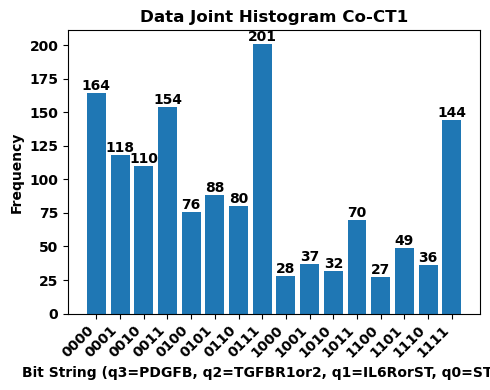

Joint Counts: Counter({'0111': 201, '0000': 164, '0011': 154, '1111': 144, '0001': 118, '0010': 110, '0101': 88, '0110': 80, '0100': 76, '1011': 70, '1101': 49, '1001': 37, '1110': 36, '1010': 32, '1000': 28, '1100': 27})
Bit Strings: ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


In [8]:
joint_counts_ct1_co, bit_strings_ct1_co = create_joint_histogram(Xct1_binary_co)
#joint_counts_ct1_co, bit_strings_ct1_co = create_percent_joint_histogram(Xct1_binary_co)

num_qubits = Xct1_binary_co.shape[1] 
plot_joint_histogram(joint_counts_ct1_co, num_qubits = num_qubits, features=gl_source, figsize = (5,4), filename = 'joint_counts_co_ct1.svg', title='Data Joint Histogram Co-CT1' )  # Pass num_qubits
#plot_joint_histogram(histogram_data, figsize=(5,4), filename = 'hist_cc_3_4pi.svg', title= r'Histogram $Ry(3\pi/4)$' )

print("Joint Counts:", joint_counts_ct1_co)
print("Bit Strings:", bit_strings_ct1_co)

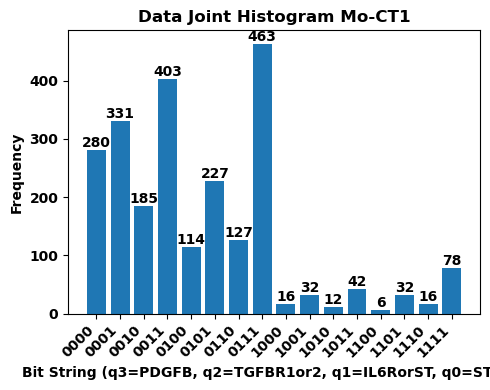

Joint Counts: Counter({'0111': 463, '0011': 403, '0001': 331, '0000': 280, '0101': 227, '0010': 185, '0110': 127, '0100': 114, '1111': 78, '1011': 42, '1101': 32, '1001': 32, '1110': 16, '1000': 16, '1010': 12, '1100': 6})
Bit Strings: ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


In [9]:
joint_counts_ct1_mo, bit_strings_ct1_mo = create_joint_histogram(Xct1_binary_mo)
#joint_counts_ct1_mo, bit_strings_ct1_mo = create_percent_joint_histogram(Xct1_binary_mo)

num_qubits = Xct1_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct1_mo, num_qubits = num_qubits, features=gl_source, figsize = (5,4), filename = 'joint_counts_mo_ct1.svg', title='Data Joint Histogram Mo-CT1' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct1_mo)
print("Bit Strings:", bit_strings_ct1_mo)

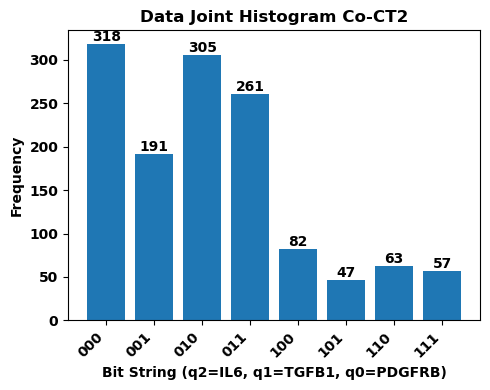

Joint Counts: Counter({'000': 318, '010': 305, '011': 261, '001': 191, '100': 82, '110': 63, '111': 57, '101': 47})
Bit Strings: ['000', '001', '010', '011', '100', '101', '110', '111']


In [10]:
joint_counts_ct2_co, bit_strings_ct2_co = create_joint_histogram(Xct2_binary_co)
#joint_counts_ct2_co, bit_strings_ct2_co = create_percent_joint_histogram(Xct2_binary_co)

num_qubits2 = Xct2_binary_co.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_co, num_qubits = num_qubits2, features=gl_recv, figsize = (5,4), filename = 'joint_counts_co_ct2.svg', title='Data Joint Histogram Co-CT2' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_co)
print("Bit Strings:", bit_strings_ct2_co)

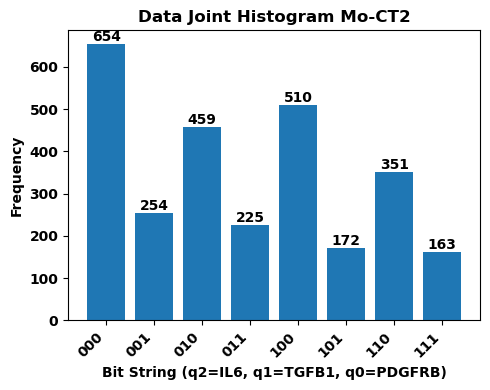

Joint Counts: Counter({'000': 654, '100': 510, '010': 459, '110': 351, '001': 254, '011': 225, '101': 172, '111': 163})
Bit Strings: ['000', '001', '010', '011', '100', '101', '110', '111']


In [11]:
joint_counts_ct2_mo, bit_strings_ct2_mo = create_joint_histogram(Xct2_binary_mo)
#joint_counts_ct2_mo, bit_strings_ct2_mo = create_percent_joint_histogram(Xct2_binary_mo)

num_qubits2 = Xct2_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_mo, num_qubits = num_qubits2, features=gl_recv, figsize = (5,4), filename = 'joint_counts_mo_ct2.svg', title='Data Joint Histogram Mo-CT2' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_mo)
print("Bit Strings:", bit_strings_ct2_mo)

In [12]:
# --- Apply and Print ---
print("--- New Dictionary Definitions ---")
print("State Set CT1 MO:", joint_counts_ct1_mo)
print("State Set CT2 MO:", joint_counts_ct2_mo)
print("Interacted State Set CT1 CO:", joint_counts_ct1_co)
print("Interacted State Set CT2 CO:", joint_counts_ct2_co)

# Apply vector normalization to the new dictionaries
normalized_joint_counts_ct1_mo = vector_normalize_dictionary_values(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = vector_normalize_dictionary_values(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = vector_normalize_dictionary_values(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = vector_normalize_dictionary_values(joint_counts_ct2_co)

print("\n--- Vector Normalized Dictionary Definitions ---")
print("Normalized State Set 5a (Vector Norm):", normalized_joint_counts_ct1_mo)
print("Normalized State Set 6a (Vector Norm):", normalized_joint_counts_ct2_mo)
print("Normalized Interacted State Set 5a (Vector Norm):", normalized_joint_counts_ct1_co)
print("Normalized Interacted State Set 6a (Vector Norm):", normalized_joint_counts_ct2_co)
# 1. Define initial circuits for concatenation
circ1 = create_initial_circuit2(normalized_joint_counts_ct1_mo)
circ2 = create_initial_circuit2(normalized_joint_counts_ct2_mo)

--- New Dictionary Definitions ---
State Set CT1 MO: Counter({'0111': 463, '0011': 403, '0001': 331, '0000': 280, '0101': 227, '0010': 185, '0110': 127, '0100': 114, '1111': 78, '1011': 42, '1101': 32, '1001': 32, '1110': 16, '1000': 16, '1010': 12, '1100': 6})
State Set CT2 MO: Counter({'000': 654, '100': 510, '010': 459, '110': 351, '001': 254, '011': 225, '101': 172, '111': 163})
Interacted State Set CT1 CO: Counter({'0111': 201, '0000': 164, '0011': 154, '1111': 144, '0001': 118, '0010': 110, '0101': 88, '0110': 80, '0100': 76, '1011': 70, '1101': 49, '1001': 37, '1110': 36, '1010': 32, '1000': 28, '1100': 27})
Interacted State Set CT2 CO: Counter({'000': 318, '010': 305, '011': 261, '001': 191, '100': 82, '110': 63, '111': 57, '101': 47})

--- Vector Normalized Dictionary Definitions ---
Normalized State Set 5a (Vector Norm): {'0000': 0.3370300821070177, '0111': 0.557303314341247, '0101': 0.2732351022796179, '1111': 0.09388695144409778, '0110': 0.15286721581282586, '0001': 0.39841

In [13]:
np.random.seed(42) 

print("\n" + "="*40)
print("--- Running N-wise Search ---")
print("="*40)

all_possible_single_cnots, best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_iterative_n_wise(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    nshots=5000,
    threshold= 0.01,
    nchoose=2
)

print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running N-wise Search ---

--- Starting Iterative Pairwise Search ---
Number of initial CNOT candidates: 42
Initial KL-divergence: 0.846342
  - Starting CNOT search -
  - No. tested pairs: 1722 | Best pair KL sum: 0.444143
  - Single CNOT insertion did not improve upon the best pair.
  - Adopted new sequence. New KL Sum: 0.444143
  - No. tested pairs: 1560 | Best pair KL sum: 0.263008
  - Single CNOT insertion did not improve upon the best pair.
  - Adopted new sequence. New KL Sum: 0.263008
  - No. tested pairs: 1406 | Best pair KL sum: 0.145070
  - Single CNOT insertion did not improve upon the best pair.
  - Adopted new sequence. New KL Sum: 0.145070
  - No. tested pairs: 1260 | Best pair KL sum: 0.142178
  - Best single CNOT insertion KL Sum: 0.141459
  - Adopted new sequence. New KL Sum: 0.141459
  - No. tested pairs: 1190 | Best pair KL sum: 0.150148
  - Best single CNOT insertion KL Sum: 0.133395
  - Adopted new sequence. New KL Sum: 0.133395
  - No. tested pairs: 1122 | Be


--- Simulating and Plotting Histograms for: CNOT Optimized Circuit ---
Counts for c_measure1: {'0101': 334, '0001': 718, '0011': 979, '0111': 1307, '0000': 487, '1101': 49, '1111': 216, '1000': 94, '1011': 174, '0110': 138, '1001': 123, '1010': 36, '0010': 220, '1110': 17, '0100': 89, '1100': 19}
Counts for c_measure2: {'001': 988, '000': 1351, '011': 1065, '010': 1500, '110': 42, '100': 21, '111': 18, '101': 15}


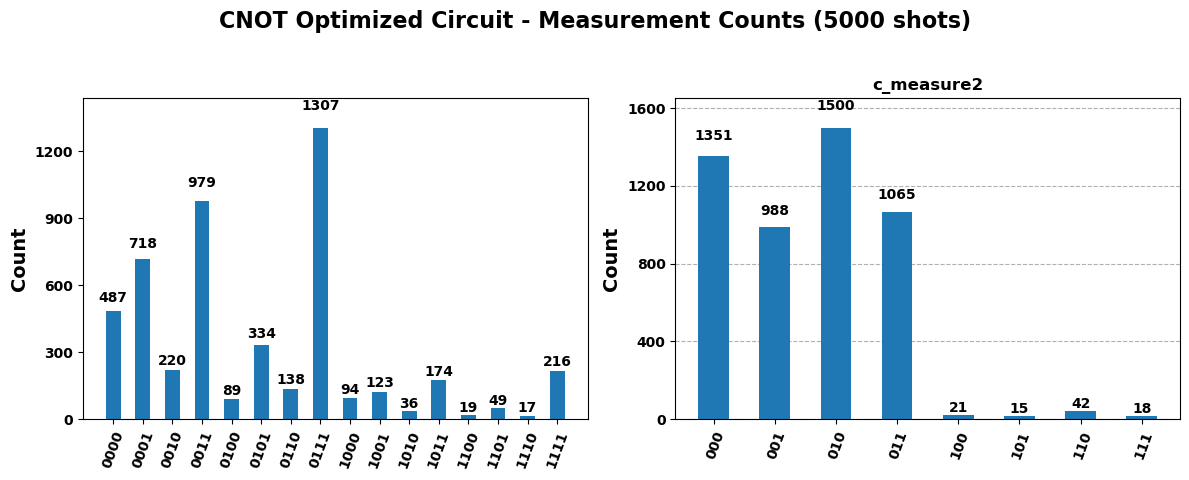

findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


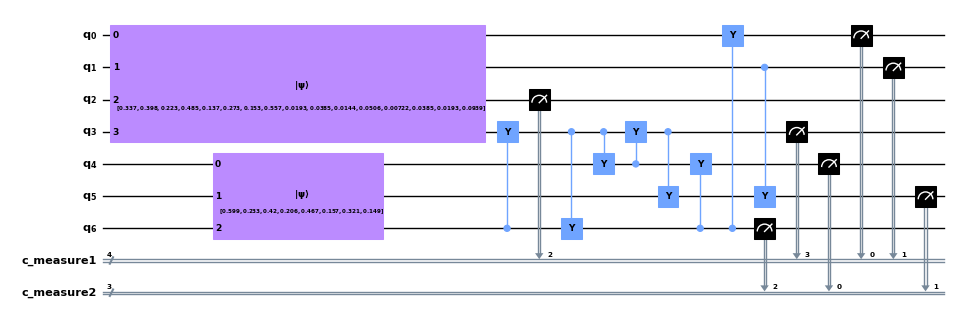

In [14]:
measure_counts1, measure_counts2 = plot_measurement_histograms( final_best_circuit_search, nshots=5000, title_prefix="CNOT Optimized Circuit")
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5)

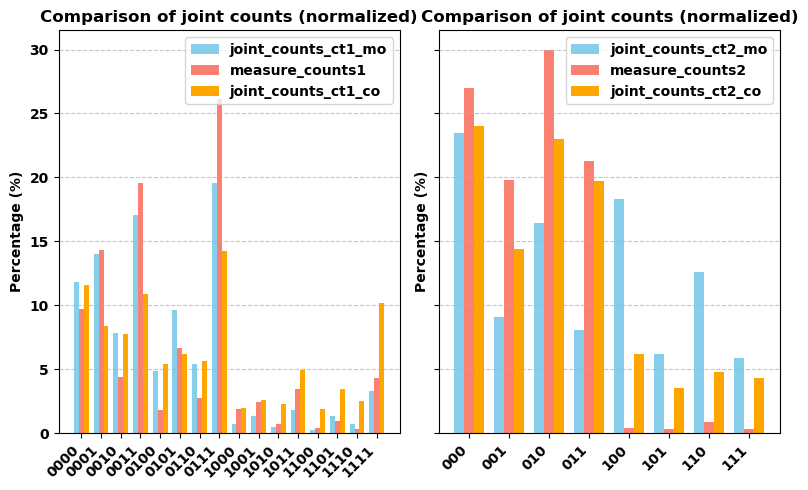

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Function to normalize dictionary values to percentages
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize all the data dictionaries
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# Combine normalized data for each subplot
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# Create a figure with a 1x2 grid of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 5), sharey=True)

# Loop through the two columns to create the plots
for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Get all unique keys for proper alignment
    all_keys = sorted(list(set(current_data[0].keys()) | set(current_data[1].keys()) | set(current_data[2].keys())))
    x = np.arange(len(all_keys))
    width = 0.25  # Bar width
    
    # Plot bars for the three datasets
    values1 = [current_data[0].get(key, 0) for key in all_keys]
    values2 = [current_data[1].get(key, 0) for key in all_keys]
    values3 = [current_data[2].get(key, 0) for key in all_keys]

    axes[i].bar(x - width, values1, width, label=current_titles[0], color='skyblue')
    axes[i].bar(x, values2, width, label=current_titles[1], color='salmon')
    axes[i].bar(x + width, values3, width, label=current_titles[2], color='orange')
    
    # Set labels, title, and legend
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=45, ha='right')
    axes[i].set_title(f'Comparison of joint counts (normalized)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend()

plt.tight_layout()
plt.savefig('normalized_counts.svg')


In [17]:
np.random.seed(42) 

print("\n" + "="*40)
print("--- Running Multi-Epoch Refined Search ---")
print("="*40)

n_epochs = 50
min_greedy_depth = 20

best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_multi_epoch(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    n_epochs=n_epochs,
    min_cnot_depth=min_greedy_depth,
    nshots=5000,
    threshold=0.0
)


print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )


    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running Multi-Epoch Refined Search ---

--- Starting Multi-Epoch Refined Search ---
Number of original CNOT candidates: 24
Number of refined CNOT candidates: 42

--- Starting Epoch 1/42 (Addition) with CNOT: (0, 5) (KL: 0.856999) ---

--- Starting Epoch 2/42 (Addition) with CNOT: (1, 3) (KL: 1.584723) ---

--- Starting Epoch 3/42 (Addition) with CNOT: (2, 5) (KL: 0.811041) ---
    --> Found a better KL on this path: 0.701771 at depth 2
    --> Found a better KL on this path: 0.638014 at depth 3
    --> Found a better KL on this path: 0.587443 at depth 4
    --> Found a better KL on this path: 0.563809 at depth 6
    --> Found a better KL on this path: 0.323019 at depth 19
    --> Found a better KL on this path: 0.274417 at depth 20
    --> Found a better KL on this path: 0.239873 at depth 21
  Epoch 3 best KL Sum: 0.239873
  --> Epoch 3 found a new overall best KL Sum: 0.239873

--- Starting Epoch 4/42 (Addition) with CNOT: (1, 4) (KL: 0.932657) ---

--- Starting Epoch 5/42 (Addit


--- Simulating and Plotting Histograms for: CNOT Optimized Circuit ---
Counts for c_measure1: {'0011': 1485, '0101': 410, '0111': 851, '0001': 622, '1011': 149, '0100': 216, '1001': 62, '0000': 351, '0010': 160, '1111': 303, '1101': 116, '0110': 116, '1000': 38, '1100': 68, '1010': 15, '1110': 38}
Counts for c_measure2: {'001': 647, '000': 1982, '010': 1239, '011': 1049, '111': 36, '100': 19, '110': 8, '101': 20}


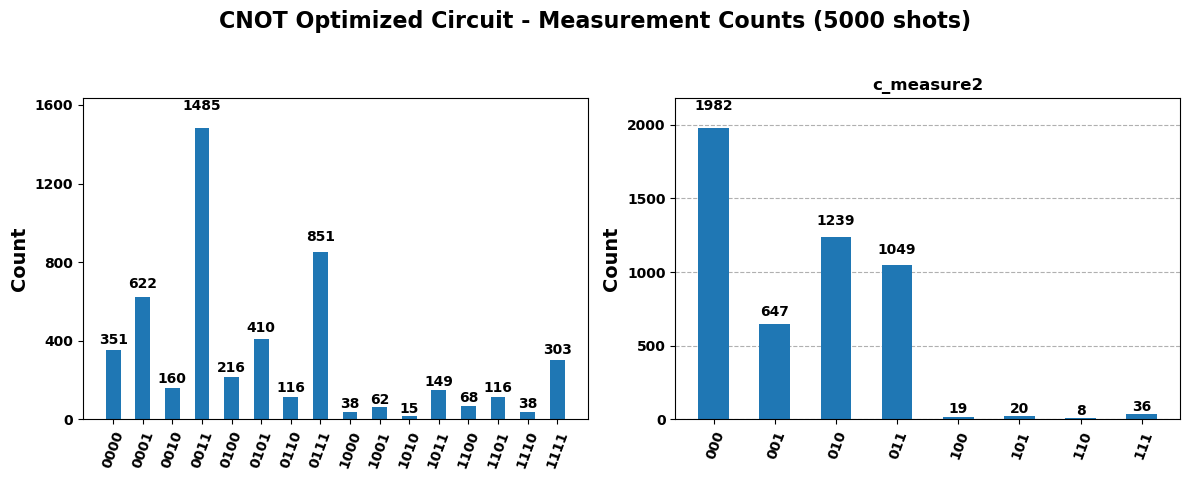

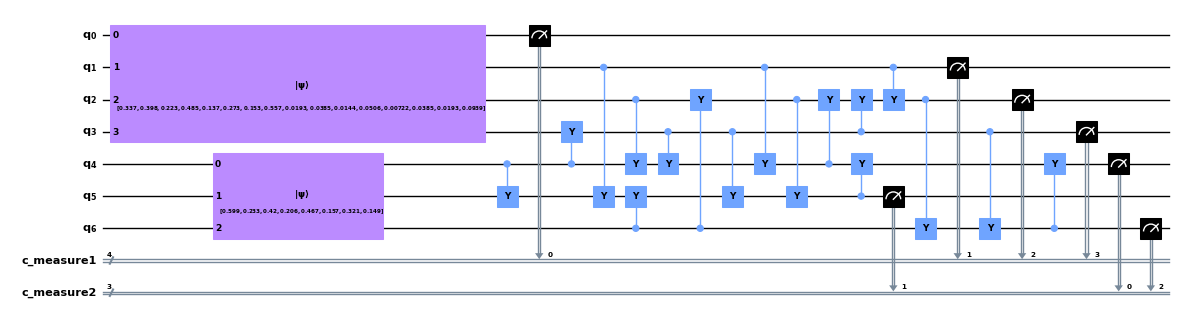

In [18]:
measure_counts1, measure_counts2 = plot_measurement_histograms( final_best_circuit_search, nshots=5000, title_prefix="CNOT Optimized Circuit")
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5)

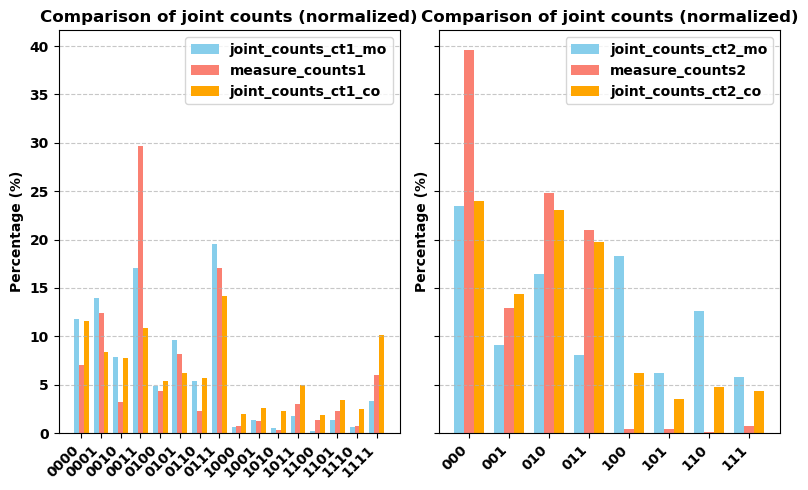

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Function to normalize dictionary values to percentages
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize all the data dictionaries
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)


# Combine normalized data for each subplot
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# Create a figure with a 1x2 grid of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 5), sharey=True)

# Loop through the two columns to create the plots
for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Get all unique keys for proper alignment
    all_keys = sorted(list(set(current_data[0].keys()) | set(current_data[1].keys()) | set(current_data[2].keys())))
    x = np.arange(len(all_keys))
    width = 0.25  # Bar width
    
    # Plot bars for the three datasets
    values1 = [current_data[0].get(key, 0) for key in all_keys]
    values2 = [current_data[1].get(key, 0) for key in all_keys]
    values3 = [current_data[2].get(key, 0) for key in all_keys]

    axes[i].bar(x - width, values1, width, label=current_titles[0], color='skyblue')
    axes[i].bar(x, values2, width, label=current_titles[1], color='salmon')
    axes[i].bar(x + width, values3, width, label=current_titles[2], color='orange')
    
    # Set labels, title, and legend
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=45, ha='right')
    axes[i].set_title(f'Comparison of joint counts (normalized)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend()

plt.tight_layout()
plt.savefig('normalized_counts.svg')



--- Running CRX Angle Optimization (based on CNOT topology) ---

--- Starting CRX Angle Optimization (17 CRX gates) ---

Optimization Results:
  Success: True
  Message: Optimization terminated successfully.
  Optimized Angles: ['2.4757', '2.9491', '2.2863', '2.1874', '2.4033', '2.0368', '1.4401', '0.6379', '2.7758', '1.2725', '2.9133', '2.4236', '1.5577', '0.4573', '3.0455', '2.7073', '2.7305']
CRX Angle Optimization took: 39.35 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['2.4757', '2.9491', '2.2863', '2.1874', '2.4033', '2.0368', '1.4401', '0.6379', '2.7758', '1.2725', '2.9133', '2.4236', '1.5577', '0.4573', '3.0455', '2.7073', '2.7305']
  Minimum Combined KL Divergence with Optimized CRX: 0.233115


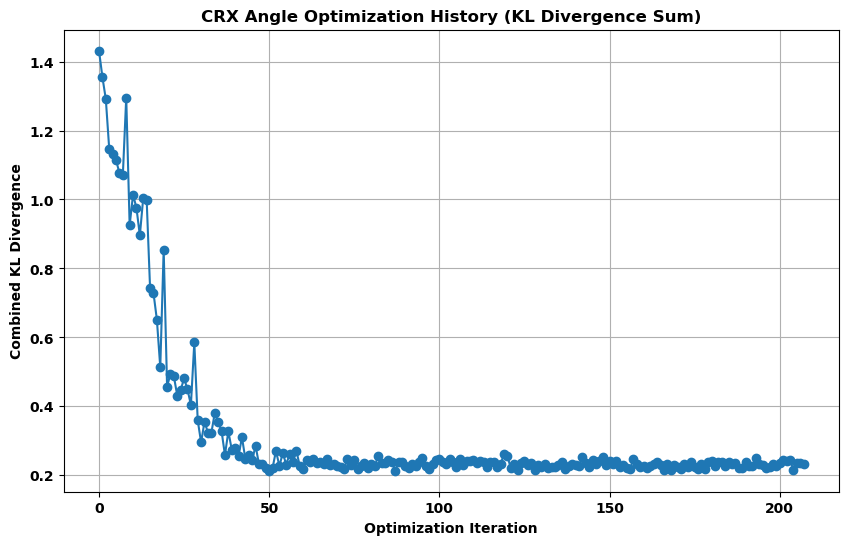


--- Final Optimized Circuit (CRX Angles) ---
              »
         q_0: »
              »
         q_1: »
              »
         q_2: »
              »
         q_3: »
              »
         q_4: »
              »
         q_5: »
              »
         q_6: »
              »
c_measure1: 4/»
              »
c_measure2: 3/»
              »
«              ┌──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐»
«         q_0: ┤0                                                                                                                                                     ├»
«              │                                                                                                                                                      │»
«         q_1: ┤1                                                                                                                              

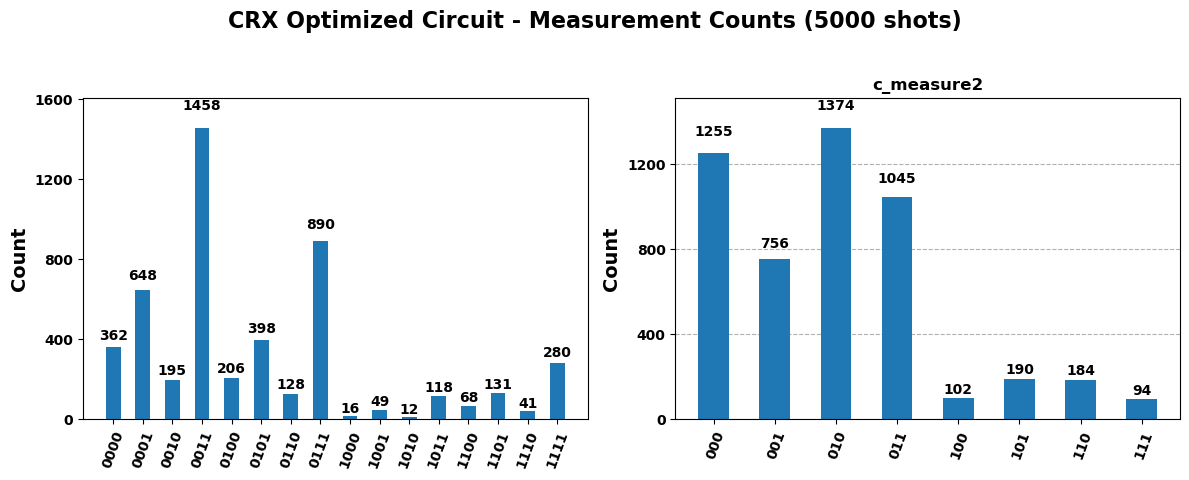

In [21]:
# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on CNOT topology) ---")
print("="*40)

optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ1,
    circ2,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    best_cnot_sequence, # Use the CNOT topology found by brute-force
    nshots=5000,
    opt_method='COBYLA', # Using L-BFGS-B COBYLA for angle optimization
    initial_angle_value= np.pi*1/2 # Start angles at pi (CNOT equivalent) | pi/2 mixed
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(10, 6))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization History (KL Divergence Sum)')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ1, circ2),
    circ1.num_qubits,
    best_cnot_sequence,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
measure_counts1, measure_counts2 = plot_measurement_histograms(final_crx_optimized_circuit, nshots=5000, title_prefix="CRX Optimized Circuit")

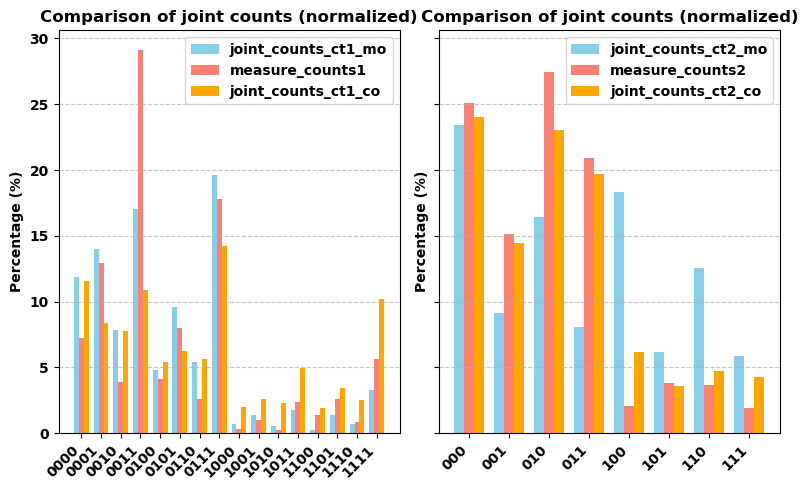

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Function to normalize dictionary values to percentages
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize all the data dictionaries
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)


# Combine normalized data for each subplot
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# Create a figure with a 1x2 grid of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 5), sharey=True)

# Loop through the two columns to create the plots
for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Get all unique keys for proper alignment
    all_keys = sorted(list(set(current_data[0].keys()) | set(current_data[1].keys()) | set(current_data[2].keys())))
    x = np.arange(len(all_keys))
    width = 0.25  # Bar width
    
    # Plot bars for the three datasets
    values1 = [current_data[0].get(key, 0) for key in all_keys]
    values2 = [current_data[1].get(key, 0) for key in all_keys]
    values3 = [current_data[2].get(key, 0) for key in all_keys]

    axes[i].bar(x - width, values1, width, label=current_titles[0], color='skyblue')
    axes[i].bar(x, values2, width, label=current_titles[1], color='salmon')
    axes[i].bar(x + width, values3, width, label=current_titles[2], color='orange')
    
    # Set labels, title, and legend
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=45, ha='right')
    axes[i].set_title(f'Comparison of joint counts (normalized)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend()

plt.tight_layout()
plt.savefig('normalized_counts_anglkes.svg')
